In [1]:
import os
from PIL import Image
import torch
from torchvision import transforms, models
import torch.nn as nn
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations
transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB (3 channels)
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for ResNet/DenseNet
])

# Load the model
model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 4)  # Modify for 4-class classification
model.load_state_dict(torch.load('model/model_110.pt'))
model.eval()
model.to(device)

# Function to measure prediction time
def measure_single_prediction_time(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transformations(image)
    image = image.to(device)
    
    # Measure prediction time
    start_time = time.time()
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        predicted_label = output.argmax(dim=1).item()  # Get the class with the highest score
    end_time = time.time()
    
    prediction_time = end_time - start_time
    return predicted_label, prediction_time

# Example usage
example_image_path = r"D:\source\data\data\test\NORMAL\CHNCXR_0029_0.png"  # Replace with your image path
predicted_label, prediction_time = measure_single_prediction_time(example_image_path)

print(f"Predicted Label: {predicted_label}")
print(f"Time Taken for Single Prediction: {prediction_time:.6f} seconds")


c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\rifat\AppData\Local\Temp\ipykernel_17188\2513431055.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/p

Predicted Label: 0
Time Taken for Single Prediction: 0.305146 seconds


c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\rifat\AppData\Local\Temp\ipykernel_30708\1393037545.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/p

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.96      0.97       548
   PNEUMONIA       0.98      0.98      0.98       427
     UNKNOWN       1.00      1.00      1.00       135
TUBERCULOSIS       0.96      0.99      0.98       417

    accuracy                           0.98      1527
   macro avg       0.98      0.98      0.98      1527
weighted avg       0.98      0.98      0.98      1527



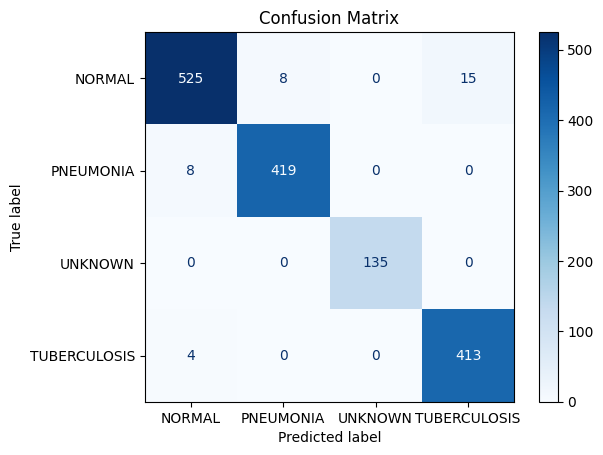

Accuracy: 97.71%


In [1]:
import os
from PIL import Image
import torch
from torchvision import transforms, models
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Define transformations
transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB (3 channels)
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for ResNet
])

model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 4)  # Modify for 4-class classification
model.load_state_dict(torch.load('model/model_110.pt'))
model.eval()
model.to(device)


# Define test dataset directories
test_dir = r"D:\source\data\data\test"
normal_dir = os.path.join(test_dir, "NORMAL")
pneumonia_dir = os.path.join(test_dir, "PNEUMONIA")
unknown_dir = os.path.join(test_dir, "UNKNOWN")  # Assuming you have an UNKNOWN directory
TUBERCULOSIS_dir = os.path.join(test_dir, "TUBERCULOSIS")  # Assuming you have an TUBERCULOSIS directory

# Initialize variables to store results
y_true = []  # Ground truth labels
y_pred = []  # Predicted labels

# Helper function to predict a single image
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transformations(image)
    image = image.to(device)
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        predicted_label = output.argmax(dim=1).item()  # Get the class with the highest score
    return predicted_label

# Evaluate NORMAL images (Ground truth label = 0)
for image_name in os.listdir(normal_dir):
    if image_name.lower().endswith(('png', 'jpg', 'jpeg', '.bmp')):
        image_path = os.path.join(normal_dir, image_name)
        y_true.append(0)  # NORMAL = 0
        y_pred.append(predict_image(image_path))

# Evaluate PNEUMONIA images (Ground truth label = 1)
for image_name in os.listdir(pneumonia_dir):
    if image_name.lower().endswith(('png', 'jpg', 'jpeg','.bmp')):
        image_path = os.path.join(pneumonia_dir, image_name)
        y_true.append(1)  # PNEUMONIA = 1
        y_pred.append(predict_image(image_path))

# Evaluate UNKNOWN images (Ground truth label = 2)
for image_name in os.listdir(unknown_dir):
    if image_name.lower().endswith(('png', 'jpg', 'jpeg','.bmp')):
        image_path = os.path.join(unknown_dir, image_name)
        y_true.append(2)  # UNKNOWN = 2
        y_pred.append(predict_image(image_path))


# Evaluate TUBERCULOSIS images (Ground truth label = 3)
for image_name in os.listdir(TUBERCULOSIS_dir):
    if image_name.lower().endswith(('png', 'jpg', 'jpeg','.bmp')):
        image_path = os.path.join(TUBERCULOSIS_dir, image_name)
        y_true.append(3)  # TUBERCULOSIS = 3
        y_pred.append(predict_image(image_path))


# Convert results to NumPy arrays
y_true = np.array(y_true) 
y_pred = np.array(y_pred)

# Classification report
report = classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA", "UNKNOWN", "TUBERCULOSIS"])
print("Classification Report:")
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA", "UNKNOWN", "TUBERCULOSIS"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Calculate accuracy
accuracy = np.sum(y_true == y_pred) / len(y_true) * 100
print(f"Accuracy: {accuracy:.2f}%")


In [ ]:
import os
from PIL import Image
import torch
from torchvision import transforms, models
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score
import numpy as np
import csv
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import time
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations
transformations = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB (3 channels)
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for ResNet
])

# Define test dataset directories
test_dir = r"D:\source\data\data\test"
normal_dir = os.path.join(test_dir, "NORMAL")
pneumonia_dir = os.path.join(test_dir, "PNEUMONIA")
unknown_dir = os.path.join(test_dir, "UNKNOWN")
TUBERCULOSIS_dir = os.path.join(test_dir, "TUBERCULOSIS")

# Initialize variables to store results
model_metrics = []  # To store metrics for each model
image_output_dir = "metrics_images"  # Folder to save images
os.makedirs(image_output_dir, exist_ok=True)  # Create folder if not exists

# Helper function to predict a single image
def predict_image(image_path, model, transformations):
    image = Image.open(image_path).convert("RGB")
    image = transformations(image)
    image = image.to(device)
    with torch.no_grad():
        output = model(image.unsqueeze(0))
        predicted_label = output.argmax(dim=1).item()  # Get the class with the highest score
    return predicted_label
# Function to save confusion matrix as an image
def save_confusion_matrix(model_name, y_true, y_pred, save_dir):
    """
    Generate and save a confusion matrix image for the given true and predicted labels.
    """
    # Define the class labels
    classes = ["NORMAL", "PNEUMONIA", "UNKNOWN", "TUBERCULOSIS"]

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display the confusion matrix with labels
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation=45)

    # Save the confusion matrix plot as an image
    plt.title(f"Confusion Matrix for {model_name}")
    image_path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(image_path)
    plt.close()

# Helper function to evaluate a model
def evaluate_model(model, transformations):
    y_true = []
    y_pred = []

    # Evaluate NORMAL images (Ground truth label = 0)
    for image_name in os.listdir(normal_dir):
        if image_name.lower().endswith(('png', 'jpg', 'jpeg', '.bmp')):
            image_path = os.path.join(normal_dir, image_name)
            y_true.append(0)  # NORMAL = 0
            y_pred.append(predict_image(image_path, model, transformations))

    # Evaluate PNEUMONIA images (Ground truth label = 1)
    for image_name in os.listdir(pneumonia_dir):
        if image_name.lower().endswith(('png', 'jpg', 'jpeg', '.bmp')):
            image_path = os.path.join(pneumonia_dir, image_name)
            y_true.append(1)  # PNEUMONIA = 1
            y_pred.append(predict_image(image_path, model, transformations))

    # Evaluate UNKNOWN images (Ground truth label = 2)
    for image_name in os.listdir(unknown_dir):
        if image_name.lower().endswith(('png', 'jpg', 'jpeg', '.bmp')):
            image_path = os.path.join(unknown_dir, image_name)
            y_true.append(2)  # UNKNOWN = 2
            y_pred.append(predict_image(image_path, model, transformations))

    # Evaluate TUBERCULOSIS images (Ground truth label = 3)
    for image_name in os.listdir(TUBERCULOSIS_dir):
        if image_name.lower().endswith(('png', 'jpg', 'jpeg', '.bmp')):
            image_path = os.path.join(TUBERCULOSIS_dir, image_name)
            y_true.append(3)  # TUBERCULOSIS = 3
            y_pred.append(predict_image(image_path, model, transformations))

    # Convert results to NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate metrics
    accuracy = np.sum(y_true == y_pred) / len(y_true) * 100
    report = classification_report(y_true, y_pred, output_dict=True, target_names=["NORMAL", "PNEUMONIA", "UNKNOWN", "TUBERCULOSIS"])
    f1 = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="weighted")

    # Save confusion matrix as an image


    return accuracy, f1, precision, report , y_true, y_pred


# Initialize the CSV file
output_csv = "model_metrics.csv"
if not os.path.exists(output_csv):
    with open(output_csv, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Model", "Accuracy", "F1 Score", "Precision", "NORMAL_F1", "NORMAL_Precision", "PNEUMONIA_F1", "PNEUMONIA_Precision", "UNKNOWN_F1", "UNKNOWN_Precision", "TUBERCULOSIS_F1", "TUBERCULOSIS_Precision"])

# Loop through all 60 models
for i in range(120):
    model_path = f'model/model_{i}.pt'
    while not os.path.exists(model_path):  # Wait until the model is created
        print(f"Model_{i} does not exist yet. Waiting for 60 seconds...")
        time.sleep(60) # Wait for 60 seconds

    try:

        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, 4)  # Modify for 4-class classification
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)

        # Evaluate the model
        accuracy, f1, precision, report , y_true , y_pred = evaluate_model(model, transformations)
        normal_f1 = report["NORMAL"]["f1-score"]
        pneumonia_f1 = report["PNEUMONIA"]["f1-score"]
        unknown_f1 = report["UNKNOWN"]["f1-score"]
        tuberculosis_f1 = report["TUBERCULOSIS"]["f1-score"]

        # Log metrics for each class
        normal_precision = report["NORMAL"]["precision"]
        pneumonia_precision = report["PNEUMONIA"]["precision"]
        unknown_precision = report["UNKNOWN"]["precision"]
        tuberculosis_precision = report["TUBERCULOSIS"]["precision"]

        save_confusion_matrix(f"model_{i}", y_true, y_pred, image_output_dir)



        # Append model metrics to the list
        model_metrics.append({
            "model": f"model_{i}",
            "accuracy": accuracy,
            "f1": f1,
            "precision": precision,
            "normal_f1": normal_f1,
            "normal_precision": normal_precision,
            "pneumonia_f1": pneumonia_f1,
            "pneumonia_precision": pneumonia_precision,
            "unknown_f1": unknown_f1,
            "unknown_precision": unknown_precision,
            "tuberculosis_f1": tuberculosis_f1,
            "tuberculosis_precision": tuberculosis_precision
        })

        # Write metrics to CSV
        with open(output_csv, mode="a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([
                f"model_{i}", accuracy, f1, precision, 
                normal_f1, normal_precision, 
                pneumonia_f1, pneumonia_precision, 
                unknown_f1, unknown_precision, 
                tuberculosis_f1, tuberculosis_precision
            ])

    except Exception as e:
        print(f"Error evaluating model_{i}: {e}")







c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rifat\miniconda3\envs\mlweb\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\rifat\AppData\Local\Temp\ipykernel_14616\4207275387.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/

Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 seconds...
Model_113 does not exist yet. Waiting for 60 sec

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the CSV file
csv_file = 'model_metrics.csv'  # Replace with your CSV file path
output_folder = 'plots'    # Folder to save the plots

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_file)

# Extract the "Model" column for labels
models = df['Model']

# Loop through each column except "Model"
for column in df.columns[1:]:
    plt.figure(figsize=(10, 6))  # Create a new figure for each plot
    plt.plot(models, df[column], marker='o', label=column)

    # Add title and labels
    plt.title(f'{column} by Model')
    plt.xlabel('Model')
    plt.ylabel(column)
    plt.xticks(rotation=45, ha='right')  # Rotate model names for better visibility
    plt.grid(True)
    plt.legend()

    # Save the plot as a PNG file in the output folder
    plot_filename = os.path.join(output_folder, f'{column}.png')
    plt.savefig(plot_filename, bbox_inches='tight')
    plt.close()  # Close the figure to free up memory

print(f'Plots have been saved in the folder: {output_folder}')


Plots have been saved in the folder: plots
